In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
import os

base_path = "../Check_data"

all_measurements = []  
measurement_id = 0      

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    # Nur Unterordner nehmen
    if os.path.isdir(folder_path):
        
        try:
            # CSVs laden
            acceleration = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
            gyroscope = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            
            acceleration["Sensor"] = "Accelerometer"
            gyroscope["Sensor"] = "Gyroscope"
            
            data = pd.concat([acceleration, gyroscope], ignore_index=True)
            
            # Zeit konvertieren 
            data["time"] = pd.to_datetime(data["time"])
            
            # Tag setzen
            data["Tag"] = tag["tag"].iloc[0]
            
            # Messungs-ID setzen
            data["ID"] = measurement_id
            
            measurement_id += 1
            
            # Speichern
            all_measurements.append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")

# Alle Messungen zusammenführen
final_df = pd.concat(all_measurements, ignore_index=True)


In [20]:
# trim the first 3 seconds and the last 3
def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

# ID als separate Spalte sichern bevor groupby sie verschluckt
final_df["ID_backup"] = final_df["ID"]

df = (
    final_df
    .groupby("ID_backup", group_keys=False)
    .apply(trim_measurement)
    .reset_index(drop=True)
)


C:\Users\rapha\AppData\Local\Temp\ipykernel_259984\3417385833.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(trim_measurement)


In [21]:
df.head()

,time,seconds_elapsed,z,y,x,Sensor,Tag,ID,ID_backup
0,2026-03-16 11:00:12.705166600,3.195167,0.380491,0.529858,4.254367,Accelerometer,Auto,0,0
1,2026-03-16 11:00:12.715075800,3.205076,-2.095479,0.276654,2.498124,Accelerometer,Auto,0,0
2,2026-03-16 11:00:12.724985000,3.214985,-0.735280,0.219567,0.268392,Accelerometer,Auto,0,0
3,2026-03-16 11:00:12.734894300,3.224894,4.304226,-0.322981,-0.307781,Accelerometer,Auto,0,0
4,2026-03-16 11:00:12.744803600,3.234803,5.247749,0.098170,2.132949,Accelerometer,Auto,0,0


In [22]:
# Check if every ID has a Tag
df.groupby(["ID"]).Tag.apply(lambda x: x.isna().any())

ID
0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
Name: Tag, dtype: bool

In [23]:
df.groupby("ID")["Tag"].unique()

ID
0       [Auto]
1       [Auto]
2       [Auto]
3       [Auto]
4       [Auto]
5       [Lift]
6       [Lift]
7     [Laufen]
8        [Zug]
9        [Zug]
10       [Zug]
11       [Zug]
12       [Zug]
13       [Zug]
14       [Zug]
15       [Zug]
16       [Zug]
17       [Zug]
18       [Zug]
19       [Zug]
20      [Lift]
Name: Tag, dtype: object

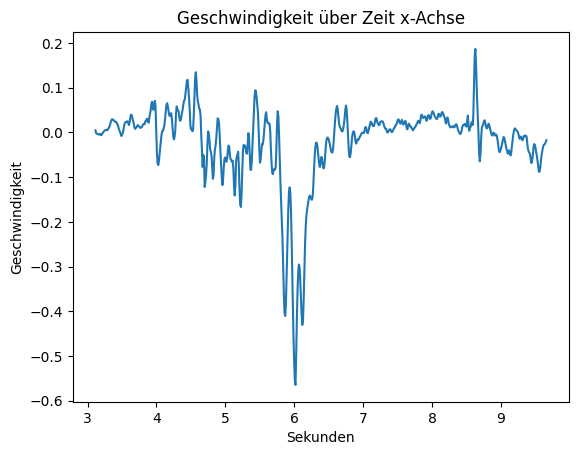

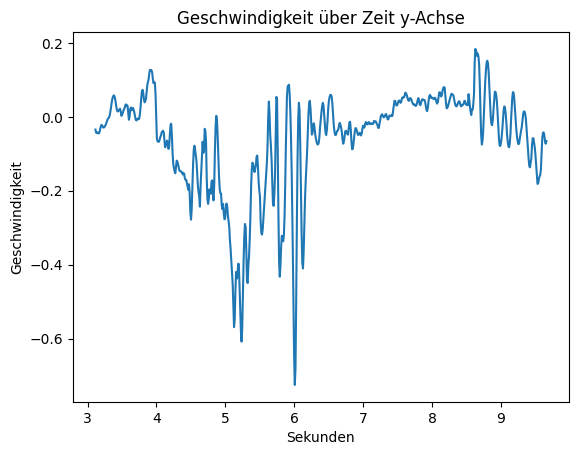

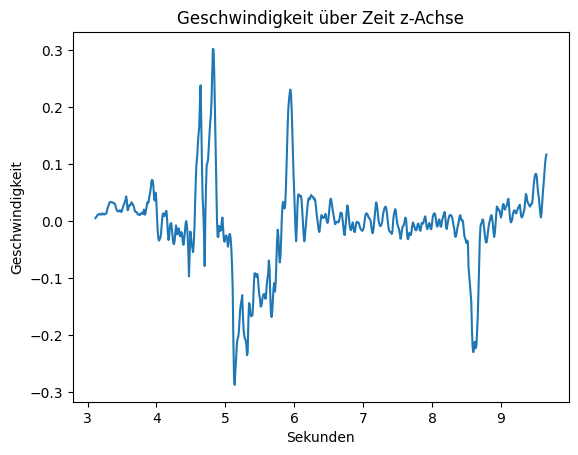

In [25]:
speed = df[(df["Sensor"] == "Gyroscope") & (df['ID'] == 20)]

#Diagramm mit Sekunden auf der x-Achse und Geschwindigkeit auf der y-Achse.
plt.plot(speed['seconds_elapsed'], speed["x"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit x-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["y"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit y-Achse")
plt.show()

plt.plot(speed['seconds_elapsed'], speed["z"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit z-Achse")
plt.show()